# Employee Attrition — Statistical Analysis
### Effect sizes, uncertainty, and adjusted associations

**Objective.** Determine whether selected employee characteristics are associated with recorded attrition, quantify the relationships, and distinguish statistical evidence from practical importance.

This project adds inference to the existing SQL and Power BI work: hypotheses, assumption checks, confidence intervals, multiple-testing control, and adjustment for measured covariates.

**Reading guide:** audit → analysis plan → descriptive context → categorical tests → numerical tests → multiplicity → correlation context → adjusted model → findings and limitations.

**Scope.** The uploaded file has no sampling design, observation window, codebook, or verified provenance. “Yes” and “No” are recorded Attrition labels. Tests and confidence intervals are conditional on a hypothetical independent sampling model; they do not establish population representativeness or causality. No claim is made that these are real employee records. This is exploratory work, not preregistered research.

In [1]:
from pathlib import Path
import hashlib
import importlib.metadata
import json
import platform
import numpy as np
import pandas as pd
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.proportion import proportion_confint, confint_proportions_2indep
from statsmodels.stats.outliers_influence import variance_inflation_factor
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

BASE = Path.cwd()
DATA = BASE / 'data' / 'WA_Fn-UseC_-HR-Employee-Attrition.csv'
assert DATA.exists(), 'Run the notebook from the project directory.'
for name in ['results', 'visualizations']:
    (BASE / name).mkdir(exist_ok=True)
ALPHA = 0.05
SEED = 20260916
rng = np.random.default_rng(SEED)
sns.set_theme(style='whitegrid', context='notebook', palette=['#326A8C', '#D07C46'])
plt.rcParams.update({'figure.dpi': 120, 'savefig.dpi': 180,
                     'axes.spines.top': False, 'axes.spines.right': False})
pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', lambda x: f'{x:.5g}')
def show_table(frame):
    with pd.option_context('display.max_rows', 100):
        display(frame)
def save_table(frame, name, index=False):
    frame.to_csv(BASE / 'results' / f'{name}.csv', index=index)
def save_plot(name):
    plt.savefig(BASE / 'visualizations' / f'{name}.png', bbox_inches='tight')
    plt.show()
def ptext(p):
    return f'{p:.3g}'
df = pd.read_csv(DATA)
print('Rows, columns:', df.shape)
print('Source SHA-256:', hashlib.sha256(DATA.read_bytes()).hexdigest())
display(df.head())

Rows, columns: (1470, 35)
Source SHA-256: a5c31e38bd7fafc9bc333884eb181b06b41b8e5e488e8f7ccb27199fb3be7659


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


## 1. Inspect before selecting tests

Every column's storage type, missingness and observed range/levels are reported. Numeric storage does not imply continuous measurement: ratings and levels are coded categories; EmployeeNumber is an identifier. Labels are preserved as supplied.

In [2]:
audit = pd.DataFrame({
    'dtype': df.dtypes.astype(str), 'missing': df.isna().sum(), 'unique': df.nunique(),
    'observed_values_or_range': [
        ', '.join(map(str, sorted(df[c].unique()))) if df[c].nunique() <= 12
        else f'{df[c].min()} to {df[c].max()}' for c in df]
})
ordinal = ['Education', 'EnvironmentSatisfaction', 'JobInvolvement', 'JobLevel',
           'JobSatisfaction', 'PerformanceRating', 'RelationshipSatisfaction',
           'StockOptionLevel', 'WorkLifeBalance']
constants = df.columns[df.nunique() == 1].tolist()
audit['analysis_role'] = [
    'outcome' if c == 'Attrition' else 'excluded: constant' if c in constants
    else 'excluded: identifier' if c == 'EmployeeNumber'
    else 'coded category; anchors undocumented' if c in ordinal
    else 'categorical' if not pd.api.types.is_numeric_dtype(df[c])
    else 'numeric; units interpreted cautiously' for c in df]
show_table(audit)
save_table(audit, 'data_audit', index=True)
print('Exact duplicate rows:', df.duplicated().sum())
print('Repeated employee identifiers:', df['EmployeeNumber'].duplicated().sum())
print('Blank strings:', sum(df[c].astype(str).str.strip().eq('').sum() for c in df))
print('Constant columns excluded from inference:', constants)
assert set(df['Attrition']) == {'No', 'Yes'}
assert not df.isna().any().any()
assert not df['EmployeeNumber'].duplicated().any()

checks = {'negative numeric values': int((df.select_dtypes('number') < 0).sum().sum()),
          'nonpositive age': int((df.Age <= 0).sum()),
          'nonpositive monthly income': int((df.MonthlyIncome <= 0).sum()),
          'company tenure exceeds working years': int((df.YearsAtCompany > df.TotalWorkingYears).sum()),
          'working years exceed age': int((df.TotalWorkingYears > df.Age).sum())}
for c in ['YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']:
    checks[f'{c} exceeds company tenure'] = int((df[c] > df.YearsAtCompany).sum())
show_table(pd.Series(checks, name='flagged_count').to_frame())
save_table(pd.Series(checks, name='flagged_count').to_frame(), 'plausibility_checks', index=True)
numeric_candidates = [c for c in df.select_dtypes('number')
                      if c not in ordinal + constants + ['EmployeeNumber']]
outliers = []
for c in numeric_candidates:
    q1, q3 = df[c].quantile([.25, .75]); iqr = q3-q1
    outliers.append({'variable': c, 'lower_fence': q1-1.5*iqr, 'upper_fence': q3+1.5*iqr,
                     'flagged_n': int(((df[c] < q1-1.5*iqr) | (df[c] > q3+1.5*iqr)).sum())})
outliers = pd.DataFrame(outliers)
show_table(outliers)
save_table(outliers, 'outlier_audit')

Exact duplicate rows: 0
Repeated employee identifiers: 0
Blank strings: 0
Constant columns excluded from inference: ['EmployeeCount', 'Over18', 'StandardHours']


,dtype,missing,unique,observed_values_or_range,analysis_role
Age,int64,0,43,18 to 60,numeric; units interpreted cautiously
Attrition,str,0,2,"No, Yes",outcome
BusinessTravel,str,0,3,"Non-Travel, Travel_Frequently, Travel_Rarely",categorical
DailyRate,int64,0,886,102 to 1499,numeric; units interpreted cautiously
Department,str,0,3,"Human Resources, Research & Development, Sales",categorical
DistanceFromHome,int64,0,29,1 to 29,numeric; units interpreted cautiously
Education,int64,0,5,"1, 2, 3, 4, 5",coded category; anchors undocumented
EducationField,str,0,6,"Human Resources, Life Sciences, Marketing, Med...",categorical
EmployeeCount,int64,0,1,1,excluded: constant
EmployeeNumber,int64,0,1470,1 to 2068,excluded: identifier


,flagged_count
negative numeric values,0
nonpositive age,0
nonpositive monthly income,0
company tenure exceeds working years,0
working years exceed age,0
YearsInCurrentRole exceeds company tenure,0
YearsSinceLastPromotion exceeds company tenure,0
YearsWithCurrManager exceeds company tenure,0


,variable,lower_fence,upper_fence,flagged_n
0,Age,10.5,62.5,0
1,DailyRate,-573,2195,0
2,DistanceFromHome,-16,32,0
3,HourlyRate,-5.625,137.38,0
4,MonthlyIncome,-5291,16581,114
5,MonthlyRate,-10575,39083,0
6,NumCompaniesWorked,-3.5,8.5,52
7,PercentSalaryHike,3,27,0
8,TotalWorkingYears,-7.5,28.5,63
9,TrainingTimesLastYear,0.5,4.5,238


**Preprocessing decisions.** Retain all records and plausible extremes; an IQR flag is not proof of error. No imputation, clipping or row removal is warranted by the audit. Exclude constants and identifiers from inference. Create binary attrition and scaled predictors only for modeling.

Plausibility rules are inferred from field names, not a substitute for a codebook. Nonnegative values and internally consistent tenure do not prove accuracy. Currency, time coverage, salary components, scale anchors and precise attrition timing are undocumented. Unique identifiers support a one-row-per-employee interpretation but cannot establish independence or rule out team clustering.

## 2. Focused analysis plan

All tests are two-sided, α = 0.05. Questions were selected after structural inspection, not by scanning all p-values. The primary family contains **10 hypotheses**, jointly adjusted with Benjamini–Hochberg (BH). Holm adjustment is a sensitivity check allowing arbitrary dependence. Narrative decisions use BH-adjusted p-values. All confidence intervals are pointwise 95%, not simultaneous.

| Question | H0 | H1 | Method and rationale |
|---|---|---|---|
| OverTime associated with attrition? | Independent | Associated | Pearson χ²; Cramér's V; interpretable proportion/ratio contrasts |
| JobRole, Department, BusinessTravel, MaritalStatus associated with attrition? | Independent, separately for each variable | At least one category differs | Four omnibus χ² tests; no unadjusted pairwise claims |
| JobSatisfaction category associated with attrition? | Independent | Associated | χ² avoids assuming equal intervals or known rating anchors |
| Mean Age differs by attrition? | μYes − μNo = 0 | Difference ≠ 0 | Welch t-test, difference in years and Hedges' g |
| Mean MonthlyIncome differs? | μYes − μNo = 0 | Difference ≠ 0 | Welch on original units; bootstrap checks skew sensitivity |
| Mean YearsAtCompany differs? | μYes − μNo = 0 | Difference ≠ 0 | Welch, unequal variance allowed; bootstrap interval |
| Mean YearsSinceLastPromotion differs? | μYes − μNo = 0 | Difference ≠ 0 | Focused promotion-history contrast, not a variable sweep |

The numerical estimand is the **arithmetic mean difference**, not a median difference. Large groups support approximate sampling-normal mean differences despite skew; bootstrap intervals check sensitivity but do not repair biased sampling. Normality p-values are not used to choose tests. ANOVA adds nothing for two groups. Mann–Whitney would answer a distributional-ordering question and is not automatically a median test.

In [3]:
categorical = ['OverTime', 'JobRole', 'Department', 'BusinessTravel', 'MaritalStatus', 'JobSatisfaction']
continuous = ['Age', 'MonthlyIncome', 'YearsAtCompany', 'YearsSinceLastPromotion']
descriptive_rows=[]
for variable in continuous:
    for group in ['No','Yes']:
        values=df.loc[df.Attrition.eq(group),variable]
        q1,q3=values.quantile([.25,.75])
        descriptive_rows.append({'variable':variable,'attrition':group,'n':len(values),
            'mean':values.mean(),'median':values.median(),'sd':values.std(),
            'q1':q1,'q3':q3,'iqr':q3-q1,'min':values.min(),'max':values.max()})
descriptive = pd.DataFrame(descriptive_rows)
show_table(descriptive)
save_table(descriptive, 'descriptive_statistics', index=True)
counts = df.Attrition.value_counts().rename('n').to_frame()
counts['percent'] = counts.n / len(df) * 100
display(counts)
frequencies=[]
for c in categorical:
    t = pd.crosstab(df[c], df.Attrition).reindex(columns=['No', 'Yes'])
    for level, row in t.iterrows():
        frequencies.append({'variable': c, 'category': str(level), 'No': row.No, 'Yes': row.Yes,
                            'total': row.sum(), 'percent_of_sample': row.sum()/len(df)*100,
                            'attrition_percent_within_category': row.Yes/row.sum()*100})
frequencies=pd.DataFrame(frequencies)
show_table(frequencies)
save_table(frequencies, 'categorical_frequencies')

,variable,attrition,n,mean,median,sd,q1,q3,iqr,min,max
0,Age,No,1233,37.561,36,8.8884,31,43,12,18,60
1,Age,Yes,237,33.608,32,9.6893,28,39,11,18,58
2,MonthlyIncome,No,1233,6832.7,5204,4818.2,3211,8834,5623,1051,19999
3,MonthlyIncome,Yes,237,4787.1,3202,3640.2,2373,5916,3543,1009,19859
4,YearsAtCompany,No,1233,7.369,6,6.0963,3,10,7,0,37
5,YearsAtCompany,Yes,237,5.1308,3,5.95,1,7,6,0,40
6,YearsSinceLastPromotion,No,1233,2.2344,1,3.2348,0,3,3,0,15
7,YearsSinceLastPromotion,Yes,237,1.9451,1,3.1531,0,2,2,0,15


,n,percent
Attrition,,
No,1233,83.878
Yes,237,16.122


,variable,category,No,Yes,total,percent_of_sample,attrition_percent_within_category
0,OverTime,No,944,110,1054,71.701,10.436
1,OverTime,Yes,289,127,416,28.299,30.529
2,JobRole,Healthcare Representative,122,9,131,8.9116,6.8702
3,JobRole,Human Resources,40,12,52,3.5374,23.077
4,JobRole,Laboratory Technician,197,62,259,17.619,23.938
5,JobRole,Manager,97,5,102,6.9388,4.902
6,JobRole,Manufacturing Director,135,10,145,9.8639,6.8966
7,JobRole,Research Director,78,2,80,5.4422,2.5
8,JobRole,Research Scientist,245,47,292,19.864,16.096
9,JobRole,Sales Executive,269,57,326,22.177,17.485


## 3. Categorical hypotheses

Pearson χ² uses counts and assumes independent observations. The code checks that every expected cell is at least 5, a conservative rule for this project. No continuity correction is applied. Cramér's V = √[χ² / (n × min(r−1,c−1))]; 0 indicates no observed association. V is unsigned and the omnibus test does not identify which individual categories differ.

In [4]:
test_rows=[]
for c in categorical:
    table=pd.crosstab(df[c], df.Attrition).reindex(columns=['No', 'Yes'])
    chi, p, dof, expected = stats.chi2_contingency(table, correction=False)
    assert expected.min() >= 5, f'{c}: sparse expected counts need another method'
    v=np.sqrt(chi/(table.to_numpy().sum()*min(table.shape[0]-1, table.shape[1]-1)))
    test_rows.append({'variable': c, 'test': 'Pearson chi-square', 'statistic': chi, 'df': dof,
                      'p_raw': p, 'effect_name': 'Cramers V', 'effect': v,
                      'min_expected': expected.min()})
    display(Markdown(f'### {c} × Attrition'))
    display(table)
    save_table(table, f'contingency_{c}', index=True)
    save_table(pd.DataFrame(expected, index=table.index, columns=table.columns), f'expected_{c}', index=True)
    print(f'χ²({dof}) = {chi:.3f}; raw p = {ptext(p)}; V = {v:.3f}; minimum expected = {expected.min():.2f}.')

χ²(1) = 89.044; raw p = 3.86e-21; V = 0.246; minimum expected = 67.07.
χ²(8) = 86.190; raw p = 2.75e-15; V = 0.242; minimum expected = 8.38.
χ²(2) = 10.796; raw p = 0.00453; V = 0.086; minimum expected = 10.16.
χ²(2) = 24.182; raw p = 5.61e-06; V = 0.128; minimum expected = 24.18.
χ²(2) = 46.164; raw p = 9.46e-11; V = 0.177; minimum expected = 52.72.
χ²(3) = 17.505; raw p = 0.000556; V = 0.109; minimum expected = 45.14.


### OverTime × Attrition

Attrition,No,Yes
OverTime,,
No,944,110
Yes,289,127


### JobRole × Attrition

Attrition,No,Yes
JobRole,,
Healthcare Representative,122,9
Human Resources,40,12
Laboratory Technician,197,62
Manager,97,5
Manufacturing Director,135,10
Research Director,78,2
Research Scientist,245,47
Sales Executive,269,57
Sales Representative,50,33


...

Attrition,No,Yes
BusinessTravel,,
Non-Travel,138,12
Travel_Frequently,208,69
Travel_Rarely,887,156


### MaritalStatus × Attrition

Attrition,No,Yes
MaritalStatus,,
Divorced,294,33
Married,589,84
Single,350,120


### JobSatisfaction × Attrition

Attrition,No,Yes
JobSatisfaction,,
1,223,66
2,234,46
3,369,73
4,407,52


### Overtime: interpretable magnitude and uncertainty

Reference = OverTime “No”; comparison = “Yes”. Risk means the **recorded attrition proportion**, not an annual prospective departure probability. Report a Newcombe score interval for the proportion difference, log-scale intervals for risk and odds ratios, and Wilson intervals for each proportion. All cells are nonzero. An odds ratio is not a risk ratio.

,contrast,estimate,ci_low,ci_high
0,Proportion difference (Yes minus No),0.20092,0.15416,0.24986
1,Risk ratio (Yes / No),2.9252,2.3273,3.6768
2,Odds ratio (Yes / No),3.7712,2.8296,5.0263


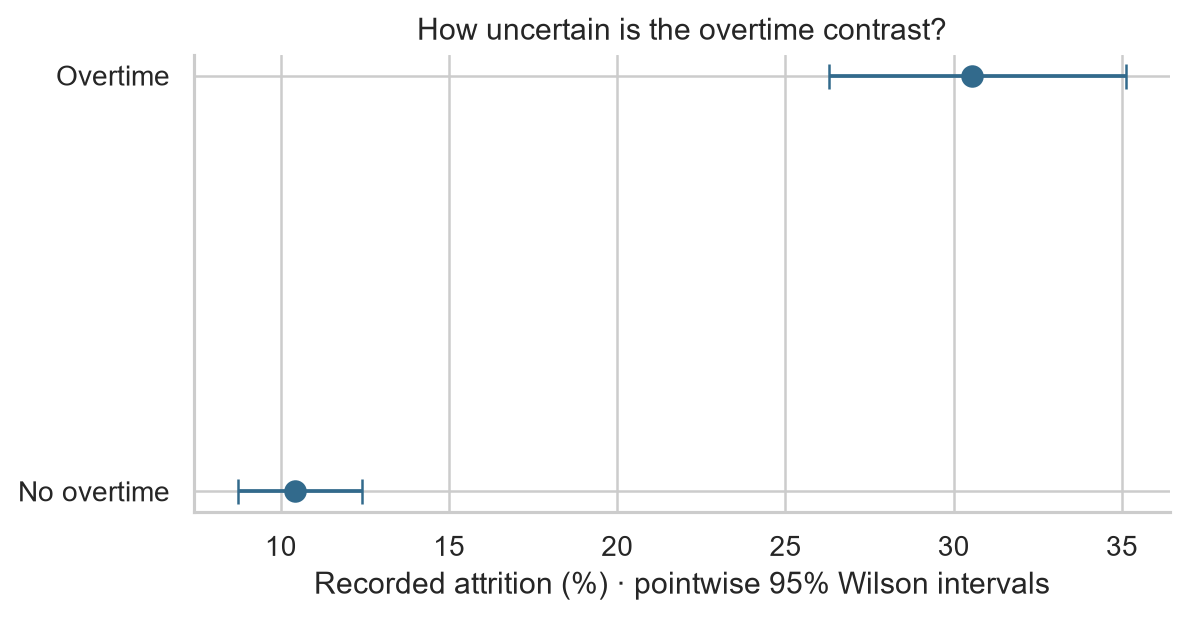

In [5]:
ot=pd.crosstab(df.OverTime,df.Attrition)
a,b=float(ot.loc['Yes','Yes']),float(ot.loc['Yes','No'])
c,d=float(ot.loc['No','Yes']),float(ot.loc['No','No'])
n1,n0=a+b,c+d
p1,p0=a/n1,c/n0
rd=p1-p0
rd_ci=confint_proportions_2indep(a,n1,c,n0,method='newcomb',compare='diff',alpha=ALPHA)
rr=p1/p0; rr_se=np.sqrt(1/a-1/n1+1/c-1/n0)
odds_ratio=a*d/(b*c); or_se=np.sqrt(1/a+1/b+1/c+1/d)
z=stats.norm.ppf(.975)
ot_effects=pd.DataFrame([
    ['Proportion difference (Yes minus No)',rd,*rd_ci],
    ['Risk ratio (Yes / No)',rr,*np.exp(np.log(rr)+np.array([-1,1])*z*rr_se)],
    ['Odds ratio (Yes / No)',odds_ratio,*np.exp(np.log(odds_ratio)+np.array([-1,1])*z*or_se)]
],columns=['contrast','estimate','ci_low','ci_high'])
display(ot_effects); save_table(ot_effects,'overtime_effects')
rates=np.array([p0,p1])
intervals=np.array([proportion_confint(c,n0,method='wilson'),proportion_confint(a,n1,method='wilson')])
fig,ax=plt.subplots(figsize=(7,3.3))
ax.errorbar(rates*100,['No overtime','Overtime'],
            xerr=np.array([rates-intervals[:,0],intervals[:,1]-rates])*100,
            fmt='o',color='#326A8C',capsize=5,markersize=8)
ax.set(xlabel='Recorded attrition (%) · pointwise 95% Wilson intervals',
       title='How uncertain is the overtime contrast?')
save_plot('overtime_confidence_intervals')

## 4. Numerical hypotheses: means and standardized effects

Box plots and standardized Q–Q plots assess skew and tails. Skewness, group SDs and variance ratios quantify departures from equal-variance normal sampling. Welch does not require equal variances. Large samples cannot establish independence.

Hedges' g is signed Yes minus No; pooled SD standardizes the effect descriptively and is not an assumption of the Welch test. Stratified nonparametric percentile bootstrap intervals use 5,000 within-group resamples and a fixed seed for both mean differences and g. These approximate pointwise intervals add sensitivity evidence without another hypothesis-test family.

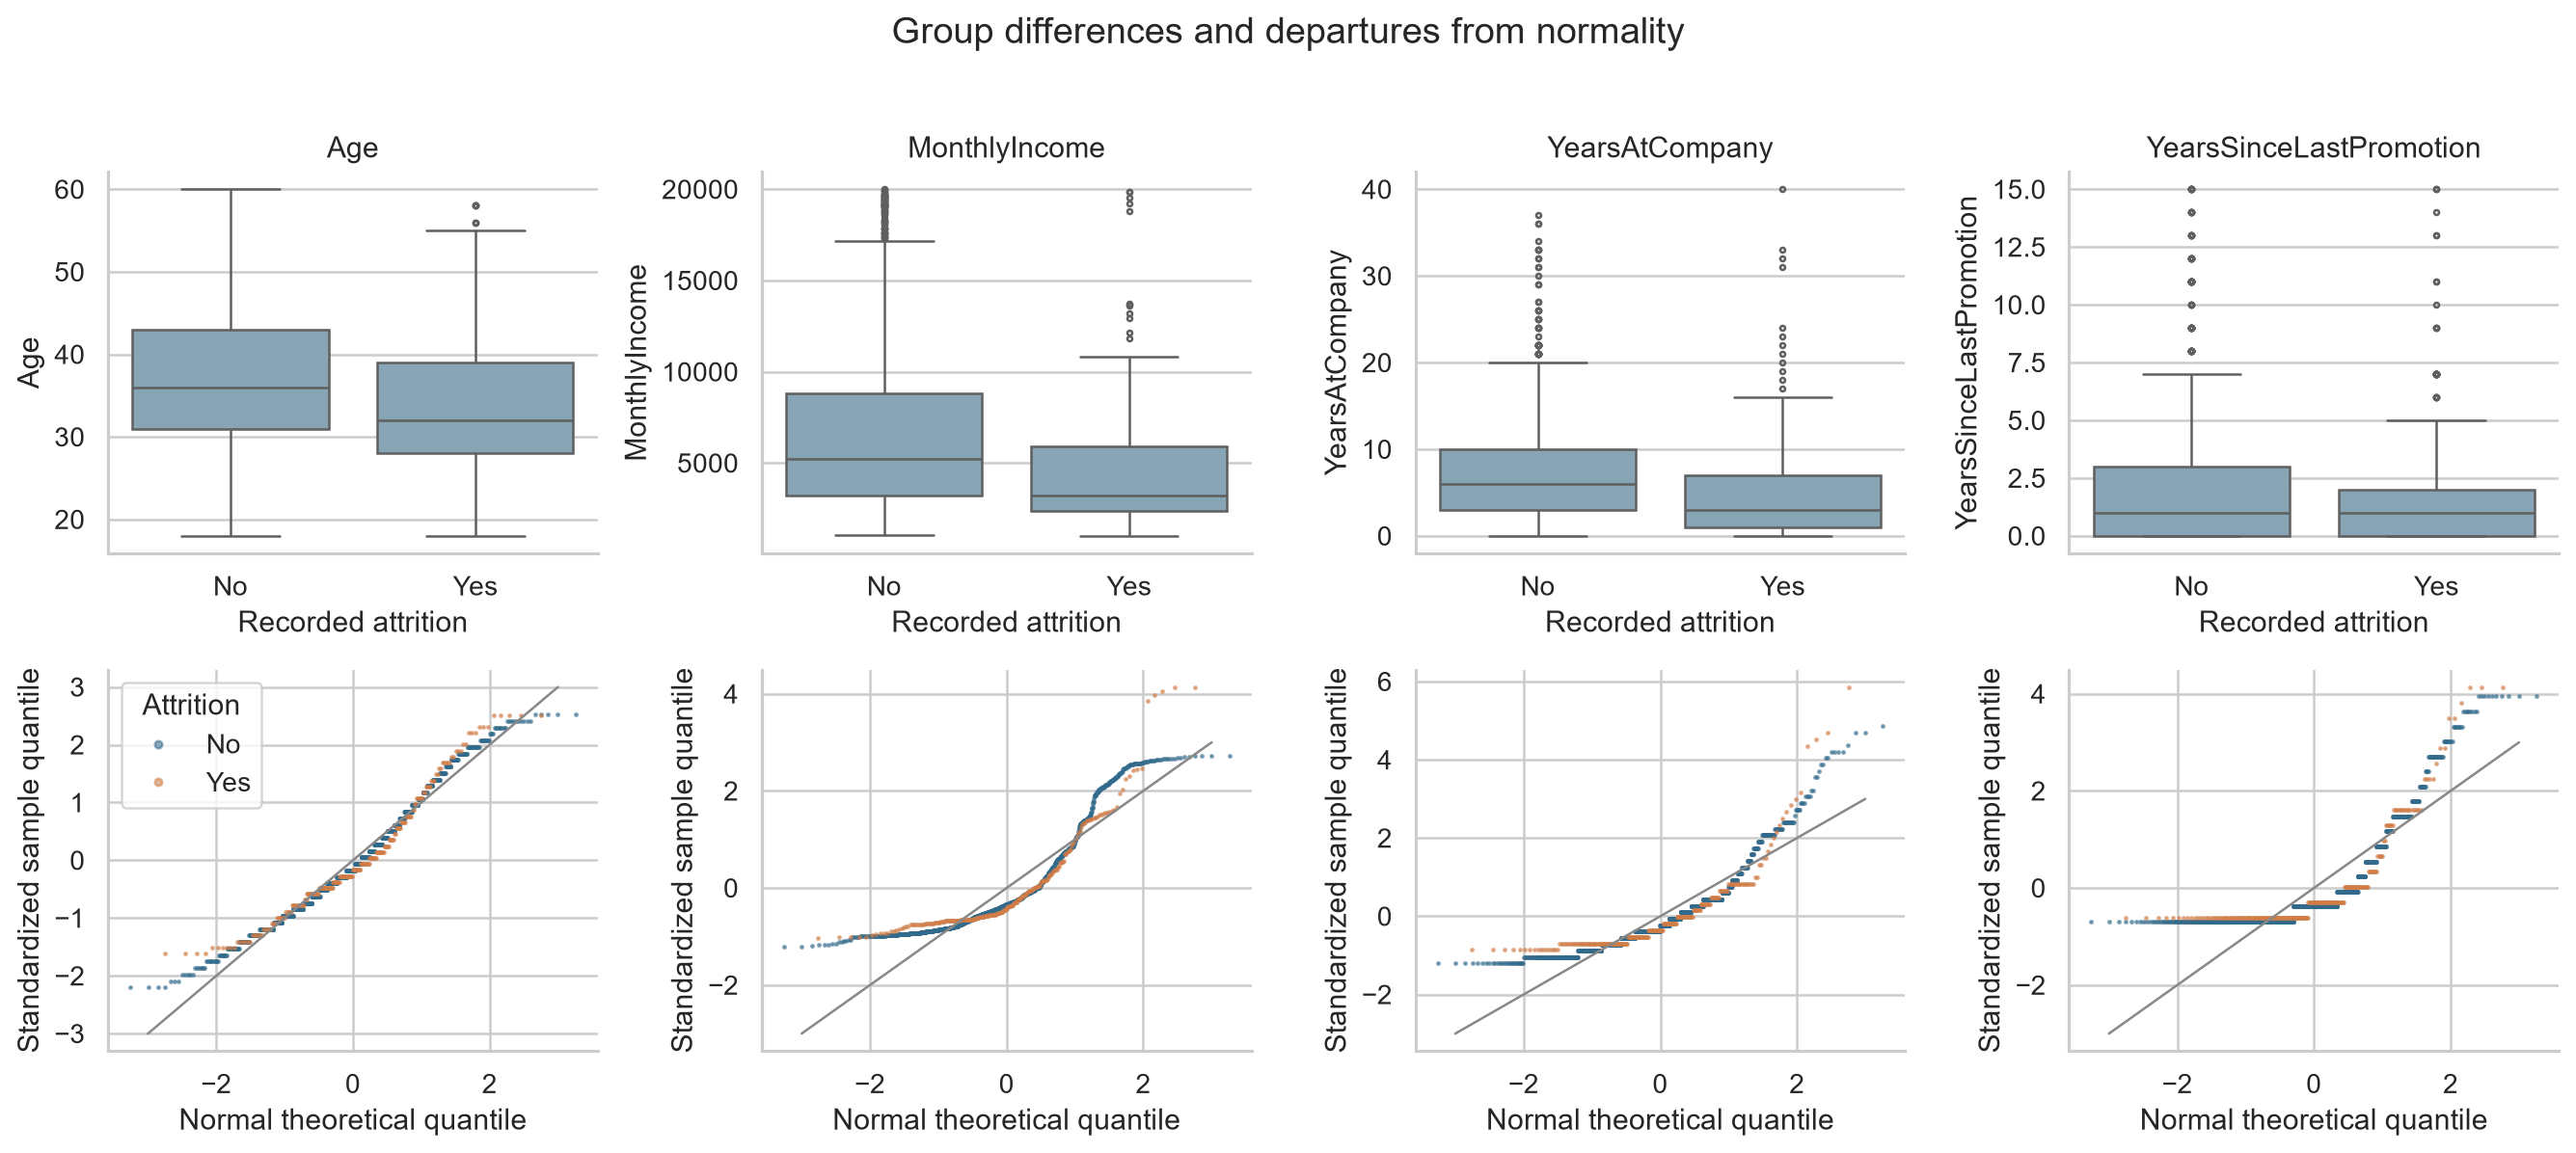

,variable,group,n,skewness,sd,variance
0,Age,No,1233,0.40812,8.8884,79.003
1,Age,Yes,237,0.71573,9.6893,93.884
2,MonthlyIncome,No,1233,1.2862,4818.2,2.3215e+07
3,MonthlyIncome,Yes,237,1.9211,3640.2,1.3251e+07
4,YearsAtCompany,No,1233,1.658,6.0963,37.165
5,YearsAtCompany,Yes,237,2.6822,5.95,35.402
6,YearsSinceLastPromotion,No,1233,1.9467,3.2348,10.464
7,YearsSinceLastPromotion,Yes,237,2.2176,3.1531,9.9419


variable
Age                        1.1884
MonthlyIncome              0.5708
YearsAtCompany            0.95258
YearsSinceLastPromotion   0.95013
Name: variance_ratio_Yes_to_No, dtype: float64

,variable,statistic,df,p_raw,mean_difference,ci_low,ci_high
0,Age,-5.828,316.93,1.3798e-08,-3.9536,-5.2883,-2.6189
1,MonthlyIncome,-7.4826,412.74,4.4336e-13,-2045.6,-2583.1,-1508.2
2,YearsAtCompany,-5.2826,338.21,2.2859e-07,-2.2382,-3.0716,-1.4048
3,YearsSinceLastPromotion,-1.2879,338.49,0.19865,-0.28924,-0.73098,0.1525


,variable,bootstrap_diff_low,bootstrap_diff_high,effect,g_ci_low,g_ci_high
0,Age,-5.2581,-2.6085,-0.438,-0.58771,-0.28897
1,MonthlyIncome,-2554,-1509.1,-0.43979,-0.54676,-0.32294
2,YearsAtCompany,-3.0067,-1.3873,-0.36836,-0.50228,-0.22657
3,YearsSinceLastPromotion,-0.72628,0.15637,-0.089731,-0.22602,0.049243


In [6]:
fig,axes=plt.subplots(2,4,figsize=(15,6.5))
diagnostics=[]
for j,c in enumerate(continuous):
    sns.boxplot(data=df,x='Attrition',y=c,order=['No','Yes'],ax=axes[0,j],color='#80A8BC',fliersize=2)
    axes[0,j].set_title(c); axes[0,j].set_xlabel('Recorded attrition')
    for label,color in [('No','#326A8C'),('Yes','#D07C46')]:
        values=df.loc[df.Attrition.eq(label),c].to_numpy()
        (theory, ordered),_=stats.probplot(values,dist='norm')
        standardized=(ordered-values.mean())/values.std(ddof=1)
        axes[1,j].plot(theory,standardized,'.',ms=2,alpha=.55,label=label,color=color)
        diagnostics.append({'variable':c,'group':label,'n':len(values),'skewness':stats.skew(values,bias=False),
                            'sd':values.std(ddof=1),'variance':values.var(ddof=1)})
    axes[1,j].plot([-3,3],[-3,3],color='#888888',lw=1)
    axes[1,j].set(xlabel='Normal theoretical quantile',ylabel='Standardized sample quantile')
axes[1,0].legend(title='Attrition',markerscale=3)
fig.suptitle('Group differences and departures from normality',y=1.02,fontsize=15)
plt.tight_layout(); save_plot('distributions_and_normality')
diagnostics=pd.DataFrame(diagnostics)
display(diagnostics); save_table(diagnostics,'numeric_diagnostics')
variance_table=diagnostics.pivot(index='variable',columns='group',values='variance')
display((variance_table['Yes']/variance_table['No']).rename('variance_ratio_Yes_to_No'))

def hedges_g(x,y):
    nx,ny=len(x),len(y)
    pooled=np.sqrt(((nx-1)*np.var(x,ddof=1)+(ny-1)*np.var(y,ddof=1))/(nx+ny-2))
    return (1-3/(4*(nx+ny)-9))*(np.mean(x)-np.mean(y))/pooled

numeric_rows=[]
for c in continuous:
    x=df.loc[df.Attrition.eq('Yes'),c].to_numpy(dtype=float)
    y=df.loc[df.Attrition.eq('No'),c].to_numpy(dtype=float)
    result=stats.ttest_ind(x,y,equal_var=False)
    ci=result.confidence_interval(.95)
    boot=np.empty((5000,2))
    for i in range(len(boot)):
        xb=rng.choice(x,len(x),replace=True); yb=rng.choice(y,len(y),replace=True)
        boot[i]=[xb.mean()-yb.mean(),hedges_g(xb,yb)]
    bci=np.quantile(boot,[.025,.975],axis=0)
    row={'variable':c,'test':'Welch t-test','statistic':result.statistic,'df':result.df,'p_raw':result.pvalue,
         'effect_name':'Hedges g','effect':hedges_g(x,y),'mean_difference':x.mean()-y.mean(),
         'ci_low':ci.low,'ci_high':ci.high,'bootstrap_diff_low':bci[0,0],'bootstrap_diff_high':bci[1,0],
         'g_ci_low':bci[0,1],'g_ci_high':bci[1,1]}
    numeric_rows.append(row); test_rows.append(row)
numeric_results=pd.DataFrame(numeric_rows)
show_table(numeric_results[['variable','statistic','df','p_raw','mean_difference','ci_low','ci_high']])
show_table(numeric_results[['variable','bootstrap_diff_low','bootstrap_diff_high','effect','g_ci_low','g_ci_high']])
save_table(numeric_results,'numeric_tests')

## 5. Multiplicity and interpretation

BH targets a 5% false discovery rate among rejected hypotheses under independence or suitable positive dependence. It does not make a specific conclusion 95% likely to be true. Holm controls family-wise error under arbitrary dependence and provides a conservative sensitivity check. All 10 tests remain visible, including non-significant findings. Failing to reject does not prove absence or equivalence.

,variable,test,statistic,df,p_raw,p_bh,p_holm,effect_name,effect,reject_bh
0,OverTime,Pearson chi-square,89.044,1,3.8615e-21,3.8615e-20,3.8615e-20,Cramers V,0.24612,True
1,JobRole,Pearson chi-square,86.19,8,2.7525e-15,1.3762e-14,2.4772e-14,Cramers V,0.24214,True
2,Department,Pearson chi-square,10.796,2,0.0045256,0.0050285,0.0090512,Cramers V,0.085698,True
3,BusinessTravel,Pearson chi-square,24.182,2,5.6086e-06,8.0123e-06,2.2434e-05,Cramers V,0.12826,True
4,MaritalStatus,Pearson chi-square,46.164,2,9.4555e-11,2.3639e-10,6.6189e-10,Cramers V,0.17721,True
5,JobSatisfaction,Pearson chi-square,17.505,3,0.0005563,0.00069538,0.0016689,Cramers V,0.10912,True
6,Age,Welch t-test,-5.828,316.93,1.3798e-08,2.7595e-08,8.2786e-08,Hedges g,-0.438,True
7,MonthlyIncome,Welch t-test,-7.4826,412.74,4.4336e-13,1.4779e-12,3.5469e-12,Hedges g,-0.43979,True
8,YearsAtCompany,Welch t-test,-5.2826,338.21,2.2859e-07,3.8098e-07,1.143e-06,Hedges g,-0.36836,True
9,YearsSinceLastPromotion,Welch t-test,-1.2879,338.49,0.19865,0.19865,0.19865,Hedges g,-0.089731,False


**OverTime.** Reject H0: evidence of an association between OverTime and attrition. Statistic = 89.044, df = 1.00; raw p = 3.86e-21, BH p = 3.86e-20. Cramér’s V = 0.246. The omnibus test does not establish individual category differences.

**JobRole.** Reject H0: evidence of an association between JobRole and attrition. Statistic = 86.190, df = 8.00; raw p = 2.75e-15, BH p = 1.38e-14. Cramér’s V = 0.242. The omnibus test does not establish individual category differences.

**Department.** Reject H0: evidence of an association between Department and attrition. Statistic = 10.796, df = 2.00; raw p = 0.00453, BH p = 0.00503. Cramér’s V = 0.086. The omnibus test does not establish individual category differences.

**BusinessTravel.** Reject H0: evidence of an association between BusinessTravel and attrition. Statistic = 24.182, df = 2.00; raw p = 5.61e-06, BH p = 8.01e-06. Cramér’s V = 0.128. The omnibus test does not establish individual category differences.

...

**JobSatisfaction.** Reject H0: evidence of an association between JobSatisfaction and attrition. Statistic = 17.505, df = 3.00; raw p = 0.000556, BH p = 0.000695. Cramér’s V = 0.109. The omnibus test does not establish individual category differences.

**Age.** Reject H0: mean Age differs between recorded attrition groups. Statistic = -5.828, df = 316.93; raw p = 1.38e-08, BH p = 2.76e-08. Yes minus No = -3.95; 95% Welch CI [-5.29, -2.62]. Hedges’ g = -0.438, bootstrap 95% CI [-0.588, -0.289].

**MonthlyIncome.** Reject H0: mean MonthlyIncome differs between recorded attrition groups. Statistic = -7.483, df = 412.74; raw p = 4.43e-13, BH p = 1.48e-12. Yes minus No = -2045.65; 95% Welch CI [-2583.05, -1508.24]. Hedges’ g = -0.440, bootstrap 95% CI [-0.547, -0.323].

**YearsAtCompany.** Reject H0: mean YearsAtCompany differs between recorded attrition groups. Statistic = -5.283, df = 338.21; raw p = 2.29e-07, BH p = 3.81e-07. Yes minus No = -2.24; 95% Welch CI [-3.07, -1.40]. Hedges’ g = -0.368, bootstrap 95% CI [-0.502, -0.227].

**YearsSinceLastPromotion.** Fail to reject H0: insufficient evidence of a mean YearsSinceLastPromotion difference. Statistic = -1.288, df = 338.49; raw p = 0.199, BH p = 0.199. Yes minus No = -0.29; 95% Welch CI [-0.73, 0.15]. Hedges’ g = -0.090, bootstrap 95% CI [-0.226, 0.049].

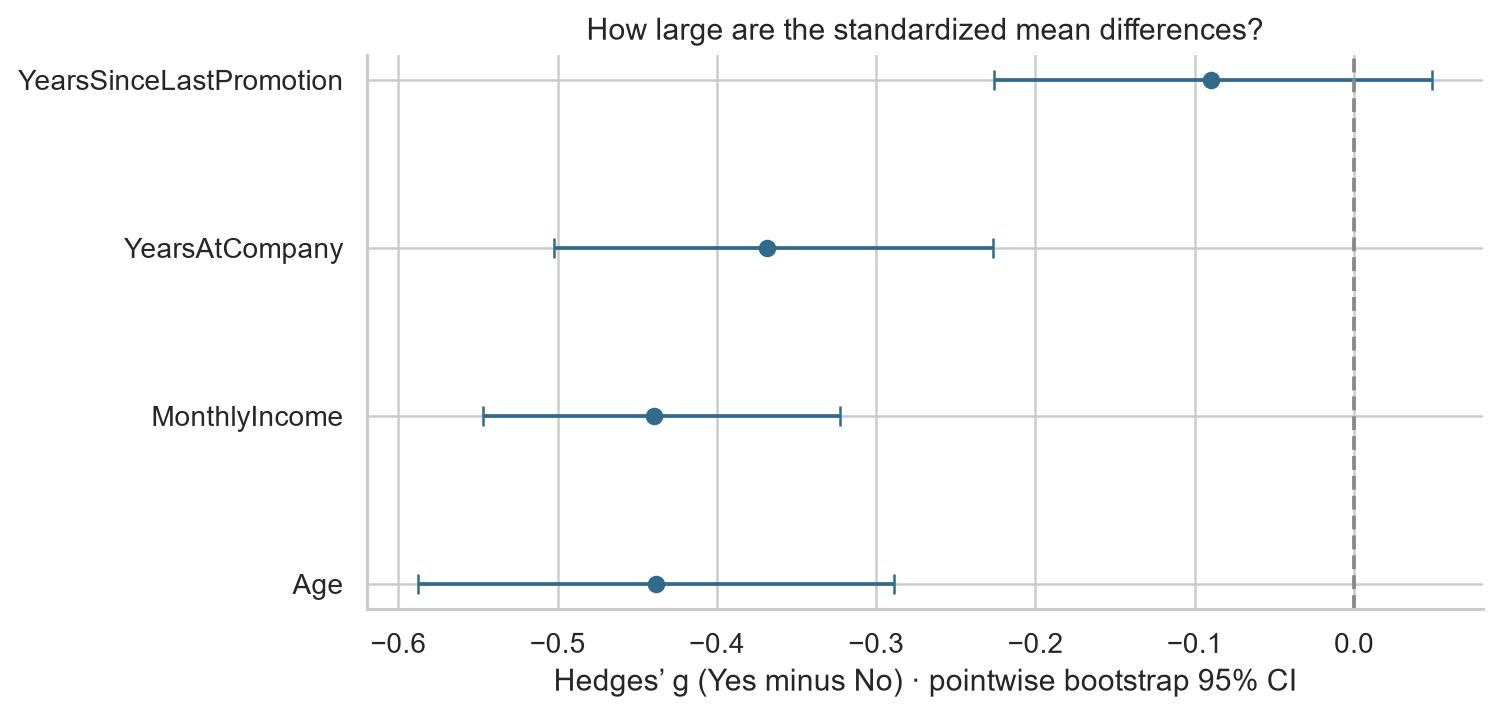

In [7]:
tests=pd.DataFrame(test_rows)
tests['p_bh']=multipletests(tests.p_raw,alpha=ALPHA,method='fdr_bh')[1]
tests['p_holm']=multipletests(tests.p_raw,alpha=ALPHA,method='holm')[1]
tests['reject_bh']=tests.p_bh < ALPHA
show_table(tests[['variable','test','statistic','df','p_raw','p_bh','p_holm','effect_name','effect','reject_bh']])
save_table(tests,'primary_tests')
interpretations=[]
for _,r in tests.iterrows():
    decision='Reject H0' if r.reject_bh else 'Fail to reject H0'
    if r.variable in categorical:
        conclusion=(f'{decision}: evidence of an association between {r.variable} and attrition' if r.reject_bh
                    else f'{decision}: insufficient evidence of an association for {r.variable}')
        detail=f'Cramér’s V = {r.effect:.3f}. The omnibus test does not establish individual category differences.'
    else:
        conclusion=(f'{decision}: mean {r.variable} differs between recorded attrition groups' if r.reject_bh
                    else f'{decision}: insufficient evidence of a mean {r.variable} difference')
        detail=(f'Yes minus No = {r.mean_difference:.2f}; 95% Welch CI [{r.ci_low:.2f}, {r.ci_high:.2f}]. '
                f'Hedges’ g = {r.effect:.3f}, bootstrap 95% CI [{r.g_ci_low:.3f}, {r.g_ci_high:.3f}].')
    text=f'**{r.variable}.** {conclusion}. Statistic = {r.statistic:.3f}, df = {r.df:.2f}; raw p = {ptext(r.p_raw)}, BH p = {ptext(r.p_bh)}. {detail}'
    interpretations.append(text)
    display(Markdown(text))
fig,ax=plt.subplots(figsize=(8,4))
ax.errorbar(numeric_results.effect,numeric_results.variable,
            xerr=[numeric_results.effect-numeric_results.g_ci_low,numeric_results.g_ci_high-numeric_results.effect],
            fmt='o',color='#326A8C',capsize=4)
ax.axvline(0,color='#888888',ls='--')
ax.set(title='How large are the standardized mean differences?',
       xlabel='Hedges’ g (Yes minus No) · pointwise bootstrap 95% CI')
save_plot('standardized_mean_differences')

**Practical importance.** Years and income units are more interpretable than p-values. No actionable minimum effect or intervention cost is supplied. Conventional g/V cutoffs are not business decision rules. Small nonzero associations can be significant at this sample size. Overtime's proportion difference motivates investigation but cannot estimate the benefit of reducing overtime.

## 6. Correlation as model context

Restrict correlation to Age, MonthlyIncome, YearsAtCompany and TotalWorkingYears, where shared career progression may create redundant predictors. Spearman's ρ describes monotonic direction and strength without requiring linearity. H0: population rank correlation is zero; H1: nonzero. Independence remains assumed; asymptotic p-values with ties are approximate.

These six diagnostic tests are a separate BH-adjusted exploratory family, not additional attrition discoveries. Larger absolute ρ means stronger monotonic association. Correlation does not imply causation.

In [8]:
from itertools import combinations
corr_vars=['Age','MonthlyIncome','YearsAtCompany','TotalWorkingYears']
corr_rows=[]
for left,right in combinations(corr_vars,2):
    result=stats.spearmanr(df[left],df[right])
    corr_rows.append({'variable_1':left,'variable_2':right,'rho':result.statistic,'p_raw':result.pvalue})
correlations=pd.DataFrame(corr_rows)
correlations['p_bh']=multipletests(correlations.p_raw,method='fdr_bh')[1]
show_table(correlations); save_table(correlations,'correlations')
for _,r in correlations.iterrows():
    print(f'{r.variable_1} and {r.variable_2}: rho={r.rho:.3f}; BH p={ptext(r.p_bh)}.')
display(Markdown('Positive coefficients indicate higher values tending to occur together. Shared variation motivates omitting TotalWorkingYears from the compact model alongside age and tenure; correlation alone does not prove harmful model collinearity.'))

Age and MonthlyIncome: rho=0.472; BH p=3.28e-82.
Age and YearsAtCompany: rho=0.252; BH p=1.13e-22.
Age and TotalWorkingYears: rho=0.657; BH p=8.77e-182.
MonthlyIncome and YearsAtCompany: rho=0.464; BH p=2.11e-79.
MonthlyIncome and TotalWorkingYears: rho=0.710; BH p=4.39e-225.
YearsAtCompany and TotalWorkingYears: rho=0.594; BH p=1.04e-140.


,variable_1,variable_2,rho,p_raw,p_bh
0,Age,MonthlyIncome,0.4719,2.1835e-82,3.2752e-82
1,Age,YearsAtCompany,0.25169,1.1287e-22,1.1287e-22
2,Age,TotalWorkingYears,0.6569,2.9241e-182,8.7722e-182
3,MonthlyIncome,YearsAtCompany,0.46432,1.7613e-79,2.1135e-79
4,MonthlyIncome,TotalWorkingYears,0.71002,7.3117e-226,4.387e-225
5,YearsAtCompany,TotalWorkingYears,0.59419,5.1933e-141,1.0387e-140


Positive coefficients indicate higher values tending to occur together. Shared variation motivates omitting TotalWorkingYears from the compact model alongside age and tenure; correlation alone does not prove harmful model collinearity.

## 7. Adjusted logistic regression

Model Attrition “Yes” as 1. Covariates are overtime, age (per 10 years), log₂ monthly income (per doubling), tenure (per 5 years), and categorical job satisfaction. This compact explanatory extension asks whether associations persist conditional on these characteristics. Selection is conceptual, with no stepwise p-value search or predictive optimization.

TotalWorkingYears overlaps career stage. JobRole, Department, travel, marital status and other potential confounders are not all represented; this is **not** a fully adjusted causal model. Log income expresses proportional income changes. Categorical satisfaction avoids assuming equal spacing; code 1 is the reference with no invented verbal anchor.

For every coefficient, H0: β = 0 (OR = 1), H1: β ≠ 0. Report two-sided Wald z-tests and pointwise 95% Wald intervals. A separate BH family contains all seven non-intercept coefficients. These exploratory findings are not independent replication of the primary tests.

Diagnostics: convergence, design rank, events per parameter, VIF, fitted probability range, and Cook's distance. A joint likelihood-ratio comparison adds three quadratic terms (H0: all three added coefficients are zero). This limited functional-form check is diagnostic; non-significance cannot prove correct specification.

In [9]:
model_data=df.assign(attrition_yes=df.Attrition.eq('Yes').astype(int), age10=df.Age/10,
                     log2_income=np.log2(df.MonthlyIncome),tenure5=df.YearsAtCompany/5)
formula='attrition_yes ~ C(OverTime, Treatment(reference="No")) + age10 + log2_income + tenure5 + C(JobSatisfaction, Treatment(reference=1))'
model=smf.glm(formula,data=model_data,family=sm.families.Binomial()).fit()
ci=model.conf_int()
model_results=pd.DataFrame({'coefficient':model.params,'std_error':model.bse,'z':model.tvalues,'p_raw':model.pvalues,
                            'odds_ratio':np.exp(model.params),'ci_low':np.exp(ci[0]),'ci_high':np.exp(ci[1])})
non_intercept=model_results.index != 'Intercept'
model_results['p_bh']=np.nan
model_results.loc[non_intercept,'p_bh']=multipletests(model_results.loc[non_intercept,'p_raw'],method='fdr_bh')[1]
show_table(model_results); save_table(model_results,'logistic_regression',index=True)
X=model.model.exog
vifs=pd.DataFrame({'term':model.model.exog_names,'VIF':[variance_inflation_factor(X,i) for i in range(X.shape[1])]})
display(vifs); save_table(vifs,'model_vif')
expanded=smf.glm(formula+' + I(age10 ** 2) + I(log2_income ** 2) + I(tenure5 ** 2)',
                 data=model_data,family=sm.families.Binomial()).fit()
lr_stat=2*(expanded.llf-model.llf); lr_df=expanded.df_model-model.df_model
lr_p=stats.chi2.sf(lr_stat,lr_df)
influence=model.get_influence()
cooks=influence.cooks_distance[0]
flagged=cooks > 4/len(df)
diag={'converged':bool(model.converged),'n':int(model.nobs),'events':int(model_data.attrition_yes.sum()),
      'slope_parameters':int(model.df_model),'events_per_slope_parameter':model_data.attrition_yes.sum()/model.df_model,
      'design_rank':int(np.linalg.matrix_rank(X)),'design_columns':X.shape[1],
      'minimum_fitted_probability':float(model.fittedvalues.min()),'maximum_fitted_probability':float(model.fittedvalues.max()),
      'max_cooks_distance':float(cooks.max()),'cooks_above_4_over_n':int(flagged.sum()),
      'quadratic_LR_statistic':lr_stat,'quadratic_LR_df':lr_df,'quadratic_LR_p':lr_p}
show_table(pd.Series(diag,name='value').to_frame())
save_table(pd.Series(diag,name='value').to_frame(),'model_diagnostics',index=True)
assert model.converged and np.linalg.matrix_rank(X)==X.shape[1]
assert np.isfinite(model.params).all()
if flagged.any():
    # Delete each of the ten largest-influence observations separately.
    case_coefficients=[]
    for position in np.argsort(cooks)[-10:]:
        subset=model_data.drop(model_data.index[position])
        sensitivity=smf.glm(formula,data=subset,family=sm.families.Binomial()).fit()
        case_coefficients.append(np.exp(sensitivity.params))
    case_results=pd.DataFrame(case_coefficients)
    stability=pd.DataFrame({'full_OR':np.exp(model.params),
        'one_case_deletion_min_OR':case_results.min(),'one_case_deletion_max_OR':case_results.max()})
    display(stability); save_table(stability,'influence_sensitivity',index=True)
display(Markdown(f'The quadratic comparison gives LR χ²({int(lr_df)}) = {lr_stat:.3f}, p = {ptext(lr_p)}. '+
    ('Evidence of curvature means simple-model ORs require caution.' if lr_p<ALPHA else
     'This check does not detect curvature; it does not validate the full model.')))
display(Markdown('All observations remain in the main model. Each of the ten largest Cook’s-distance cases is omitted separately for a limited influence check; this does not assess every possible multi-case perturbation. Convergence, finite coefficients and probability range provide no obvious separation warning, but do not prove adequacy.'))
for term,r in model_results.loc[non_intercept].iterrows():
    decision='evidence of an adjusted association' if r.p_bh<ALPHA else 'insufficient evidence after coefficient-family BH correction'
    display(Markdown(f'**{term}**: adjusted OR {r.odds_ratio:.2f} (95% CI {r.ci_low:.2f}–{r.ci_high:.2f}), Wald z={r.z:.2f}, raw p={ptext(r.p_raw)}, BH p={ptext(r.p_bh)}; {decision}. Other included covariates are held fixed.'))

,coefficient,std_error,z,p_raw,odds_ratio,ci_low,ci_high,p_bh
Intercept,5.389,1.2024,4.4818,7.403e-06,218.98,20.744,2311.6,NaN
"C(OverTime, Treatment(reference=""No""))[T.Yes]",1.4754,0.1558,9.4699,2.8022e-21,4.3729,3.2222,5.9345,1.9615e-20
"C(JobSatisfaction, Treatment(reference=1))[T.2]",-0.45251,0.23152,-1.9545,0.050642,0.63603,0.40403,1.0013,0.059082
"C(JobSatisfaction, Treatment(reference=1))[T.3]",-0.45828,0.20433,-2.2429,0.024905,0.63237,0.42369,0.94383,0.034867
"C(JobSatisfaction, Treatment(reference=1))[T.4]",-1.0076,0.21835,-4.6146,3.9378e-06,0.36509,0.23798,0.56009,1.3782e-05
age10,-0.30154,0.099338,-3.0355,0.0024015,0.73968,0.60882,0.89867,0.0042027
log2_income,-0.48161,0.1089,-4.4227,9.7464e-06,0.61779,0.49905,0.76477,2.2742e-05
tenure5,-0.13846,0.091439,-1.5142,0.12997,0.8707,0.72784,1.0416,0.12997


,term,VIF
0,Intercept,1
1,"C(OverTime, Treatment(reference=""No""))[T.Yes]",1.0038
2,"C(JobSatisfaction, Treatment(reference=1))[T.2]",1.5962
3,"C(JobSatisfaction, Treatment(reference=1))[T.3]",1.77
4,"C(JobSatisfaction, Treatment(reference=1))[T.4]",1.7806
5,age10,1.3336
6,log2_income,1.6225
7,tenure5,1.3574


,value
converged,True
n,1470
events,237
slope_parameters,7
events_per_slope_parameter,33.857
design_rank,8
design_columns,8
minimum_fitted_probability,0.00582
maximum_fitted_probability,0.73966
max_cooks_distance,0.048394


,full_OR,one_case_deletion_min_OR,one_case_deletion_max_OR
Intercept,218.98,189.05,253.49
"C(OverTime, Treatment(reference=""No""))[T.Yes]",4.3729,4.3303,4.4512
"C(JobSatisfaction, Treatment(reference=1))[T.2]",0.63603,0.61617,0.63625
"C(JobSatisfaction, Treatment(reference=1))[T.3]",0.63237,0.61945,0.63234
"C(JobSatisfaction, Treatment(reference=1))[T.4]",0.36509,0.35454,0.36488
age10,0.73968,0.72142,0.74298
log2_income,0.61779,0.61031,0.62989
tenure5,0.8707,0.82643,0.87619


The quadratic comparison gives LR χ²(3) = 31.944, p = 5.38e-07. Evidence of curvature means simple-model ORs require caution.

...

**C(JobSatisfaction, Treatment(reference=1))[T.3]**: adjusted OR 0.63 (95% CI 0.42–0.94), Wald z=-2.24, raw p=0.0249, BH p=0.0349; evidence of an adjusted association. Other included covariates are held fixed.

**C(JobSatisfaction, Treatment(reference=1))[T.4]**: adjusted OR 0.37 (95% CI 0.24–0.56), Wald z=-4.61, raw p=3.94e-06, BH p=1.38e-05; evidence of an adjusted association. Other included covariates are held fixed.

**age10**: adjusted OR 0.74 (95% CI 0.61–0.90), Wald z=-3.04, raw p=0.0024, BH p=0.0042; evidence of an adjusted association. Other included covariates are held fixed.

**log2_income**: adjusted OR 0.62 (95% CI 0.50–0.76), Wald z=-4.42, raw p=9.75e-06, BH p=2.27e-05; evidence of an adjusted association. Other included covariates are held fixed.

**tenure5**: adjusted OR 0.87 (95% CI 0.73–1.04), Wald z=-1.51, raw p=0.13, BH p=0.13; insufficient evidence after coefficient-family BH correction. Other included covariates are held fixed.

### Respond to the functional-form diagnostic

The quadratic sensitivity model allows curvature in age, log income and tenure while retaining all original predictors. Because this extension follows a diagnostic, its inference is exploratory and selection-conditional. It does not repair unmeasured confounding.

Report its full coefficient table (including quadratic coefficients), then compare interpretable contrasts between models. A quadratic predictor has **no single constant odds ratio per unit**. Instead compare age 30→40, income 3,000→6,000 dataset units, and tenure 5→10 years; these contrasts are within observed ranges. Categorical contrasts are constant across covariates because the model has no interactions. Intervals use linear contrasts of coefficients and the full covariance matrix.

The ten non-intercept coefficients form a separately labeled exploratory BH family. Seven reported contrasts also receive a separate BH adjustment; these overlapping summaries are not new independent discoveries. Each contrast tests H0: log odds contrast = 0 against H1: nonzero, using a two-sided Wald z-test.

Exponentiated individual polynomial coefficients are algebraic terms, not standalone per-unit odds ratios.
Quadratic model: 10 slope parameters; 23.7 events per slope parameter.
Raw polynomial terms can have large VIFs through algebraic dependence; contrast intervals use their covariance.
Fitted probability range: 0.015146977401639622 0.8661775750469699
Quadratic maximum Cook’s distance: 0.05100567836644442 ; cases above 4/n: 114


,coefficient,std_error,z,p_raw,exp_coefficient,exp_ci_low,exp_ci_high,p_bh
Intercept,18.879,12.4,1.5224,0.1279,1.5814e+08,0.0044029,5.68e+18,NaN
"C(OverTime, Treatment(reference=""No""))[T.Yes]",1.4868,0.15931,9.3327,1.0318e-20,4.4227,3.2366,6.0435,1.0318e-19
"C(JobSatisfaction, Treatment(reference=1))[T.2]",-0.49184,0.23622,-2.0821,0.037329,0.6115,0.38488,0.97155,0.046661
"C(JobSatisfaction, Treatment(reference=1))[T.3]",-0.4777,0.20737,-2.3037,0.021241,0.62021,0.41307,0.93121,0.035402
"C(JobSatisfaction, Treatment(reference=1))[T.4]",-1.0313,0.22267,-4.6314,3.6317e-06,0.35655,0.23045,0.55164,1.8159e-05
age10,-1.6313,0.59834,-2.7264,0.0064021,0.19567,0.060563,0.63216,0.012804
log2_income,-2.2959,2.0568,-1.1163,0.2643,0.10067,0.0017871,5.6704,0.29367
tenure5,-0.72843,0.18088,-4.0272,5.6435e-05,0.48267,0.3386,0.68803,0.0001459
I(age10 ** 2),0.17191,0.078267,2.1964,0.028061,1.1876,1.0187,1.3845,0.040088
I(log2_income ** 2),0.076383,0.083798,0.91151,0.36202,1.0794,0.91589,1.272,0.36202


,model,contrast,log_odds_contrast,z,p_raw,odds_ratio,ci_low,ci_high,p_bh
0,Simple,Overtime: Yes vs No,1.4754,9.4699,2.8022e-21,4.3729,3.2222,5.9345,1.9615e-20
1,Simple,Satisfaction code 2 vs 1,-0.45251,-1.9545,0.050642,0.63603,0.40403,1.0013,0.059082
2,Simple,Satisfaction code 3 vs 1,-0.45828,-2.2429,0.024905,0.63237,0.42369,0.94383,0.034867
3,Simple,Satisfaction code 4 vs 1,-1.0076,-4.6146,3.9378e-06,0.36509,0.23798,0.56009,1.3782e-05
4,Simple,Age: 30 to 40 years,-0.30154,-3.0355,0.0024015,0.73968,0.60882,0.89867,0.0042027
5,Simple,"Income: 3,000 to 6,000",-0.48161,-4.4227,9.7464e-06,0.61779,0.49905,0.76477,2.2742e-05
6,Simple,Tenure: 5 to 10 years,-0.13846,-1.5142,0.12997,0.8707,0.72784,1.0416,0.12997
7,Quadratic,Overtime: Yes vs No,1.4868,9.3327,1.0318e-20,4.4227,3.2366,6.0435,7.2223e-20
8,Quadratic,Satisfaction code 2 vs 1,-0.49184,-2.0821,0.037329,0.6115,0.38488,0.97155,0.037329
9,Quadratic,Satisfaction code 3 vs 1,-0.4777,-2.3037,0.021241,0.62021,0.41307,0.93121,0.024781


**Overtime: Yes vs No:** OR=4.42, pointwise 95% CI [3.24, 6.04], BH p=7.22e-20; evidence of an adjusted contrast.

**Satisfaction code 2 vs 1:** OR=0.61, pointwise 95% CI [0.38, 0.97], BH p=0.0373; evidence of an adjusted contrast.

**Satisfaction code 3 vs 1:** OR=0.62, pointwise 95% CI [0.41, 0.93], BH p=0.0248; evidence of an adjusted contrast.

**Satisfaction code 4 vs 1:** OR=0.36, pointwise 95% CI [0.23, 0.55], BH p=1.27e-05; evidence of an adjusted contrast.

**Age: 30 to 40 years:** OR=0.65, pointwise 95% CI [0.53, 0.80], BH p=0.000111; evidence of an adjusted contrast.

**Income: 3,000 to 6,000:** OR=0.63, pointwise 95% CI [0.51, 0.79], BH p=0.000111; evidence of an adjusted contrast.

**Tenure: 5 to 10 years:** OR=0.70, pointwise 95% CI [0.57, 0.86], BH p=0.00102; evidence of an adjusted contrast.

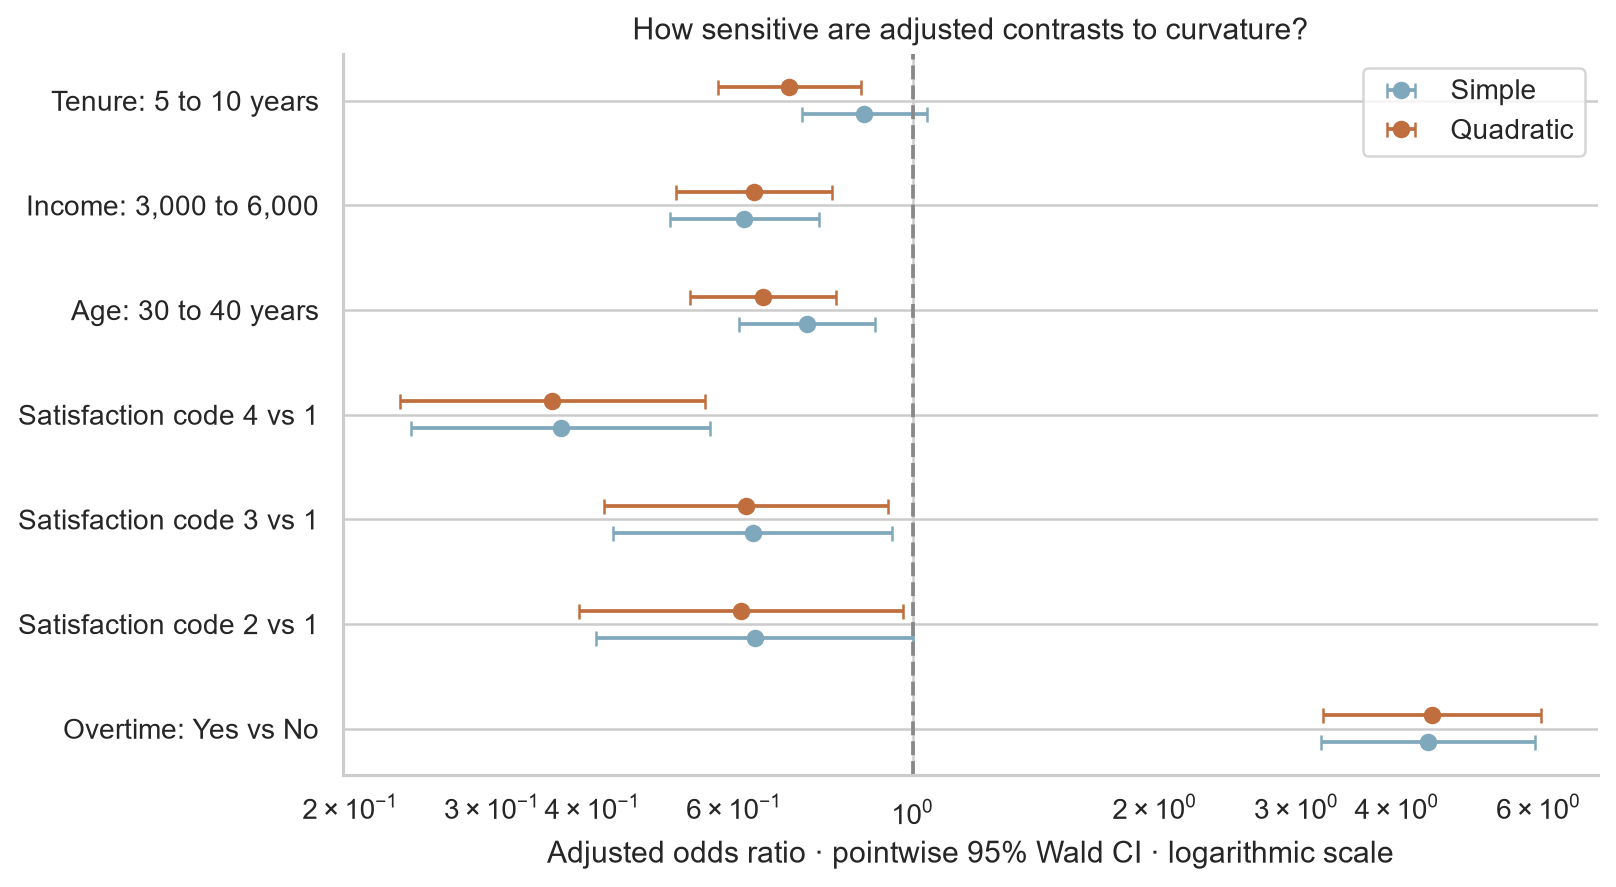

In [10]:
expanded_ci=expanded.conf_int()
expanded_results=pd.DataFrame({'coefficient':expanded.params,'std_error':expanded.bse,
    'z':expanded.tvalues,'p_raw':expanded.pvalues,'exp_coefficient':np.exp(expanded.params),
    'exp_ci_low':np.exp(expanded_ci[0]),'exp_ci_high':np.exp(expanded_ci[1])})
expanded_results['p_bh']=np.nan
expanded_results.loc[expanded_results.index!='Intercept','p_bh']=multipletests(
    expanded.pvalues.drop('Intercept'),method='fdr_bh')[1]
show_table(expanded_results)
save_table(expanded_results,'nonlinear_model_coefficients',index=True)
print('Exponentiated individual polynomial coefficients are algebraic terms, not standalone per-unit odds ratios.')
assert expanded.converged and np.linalg.matrix_rank(expanded.model.exog)==expanded.model.exog.shape[1]
expanded_vif=pd.DataFrame({'term':expanded.model.exog_names,
    'VIF':[variance_inflation_factor(expanded.model.exog,i) for i in range(expanded.model.exog.shape[1])]})
save_table(expanded_vif,'nonlinear_model_vif')
print('Quadratic model:',len(expanded.params)-1,'slope parameters;',
      round(model_data.attrition_yes.sum()/(len(expanded.params)-1),1),'events per slope parameter.')
print('Raw polynomial terms can have large VIFs through algebraic dependence; contrast intervals use their covariance.')
print('Fitted probability range:',expanded.fittedvalues.min(),expanded.fittedvalues.max())
expanded_cooks=expanded.get_influence().cooks_distance[0]
print('Quadratic maximum Cook’s distance:',expanded_cooks.max(),
      '; cases above 4/n:',int((expanded_cooks>4/len(df)).sum()))
contrast_specs=[
    ('Overtime: Yes vs No',{'C(OverTime, Treatment(reference="No"))[T.Yes]':1}),
    ('Satisfaction code 2 vs 1',{'C(JobSatisfaction, Treatment(reference=1))[T.2]':1}),
    ('Satisfaction code 3 vs 1',{'C(JobSatisfaction, Treatment(reference=1))[T.3]':1}),
    ('Satisfaction code 4 vs 1',{'C(JobSatisfaction, Treatment(reference=1))[T.4]':1}),
    ('Age: 30 to 40 years',{'age10':1,'I(age10 ** 2)':4**2-3**2}),
    ('Income: 3,000 to 6,000',{'log2_income':1,'I(log2_income ** 2)':np.log2(6000)**2-np.log2(3000)**2}),
    ('Tenure: 5 to 10 years',{'tenure5':1,'I(tenure5 ** 2)':2**2-1**2})]
contrast_rows=[]
for model_name,fitted in [('Simple',model),('Quadratic',expanded)]:
    for label,weights in contrast_specs:
        vector=np.array([weights.get(term,0) for term in fitted.params.index])
        log_or=float(vector@fitted.params)
        se=float(np.sqrt(vector@fitted.cov_params()@vector))
        contrast_rows.append({'model':model_name,'contrast':label,'log_odds_contrast':log_or,
            'z':log_or/se,'p_raw':2*stats.norm.sf(abs(log_or/se)),
            'odds_ratio':np.exp(log_or),'ci_low':np.exp(log_or-z*se),'ci_high':np.exp(log_or+z*se)})
contrasts=pd.DataFrame(contrast_rows)
contrasts['p_bh']=contrasts.groupby('model')['p_raw'].transform(lambda p:multipletests(p,method='fdr_bh')[1])
show_table(contrasts); save_table(contrasts,'adjusted_contrasts')
for _,r in contrasts.loc[contrasts.model.eq('Quadratic')].iterrows():
    verdict='evidence of an adjusted contrast' if r.p_bh<ALPHA else 'insufficient evidence after contrast-family BH correction'
    display(Markdown(f'**{r.contrast}:** OR={r.odds_ratio:.2f}, pointwise 95% CI [{r.ci_low:.2f}, {r.ci_high:.2f}], BH p={ptext(r.p_bh)}; {verdict}.'))
fig,ax=plt.subplots(figsize=(9,5.2))
positions=np.arange(len(contrast_specs))
for name,offset,color in [('Simple',-.13,'#80A8BC'),('Quadratic',.13,'#C16E3E')]:
    plot_data=contrasts.loc[contrasts.model.eq(name)]
    ax.errorbar(plot_data.odds_ratio,positions+offset,
        xerr=[plot_data.odds_ratio-plot_data.ci_low,plot_data.ci_high-plot_data.odds_ratio],
        fmt='o',color=color,capsize=3,label=name)
ax.set_yticks(positions,[label for label,_ in contrast_specs])
ax.axvline(1,color='#888888',ls='--'); ax.set_xscale('log')
ax.set(title='How sensitive are adjusted contrasts to curvature?',
       xlabel='Adjusted odds ratio · pointwise 95% Wald CI · logarithmic scale')
ax.legend(); save_plot('adjusted_odds_ratios')

An OR below 1 indicates lower modeled odds, not the same proportional reduction in probability. ORs can change with adjustment due to confounding and non-collapsibility; a change alone does not identify a causal mechanism. Wald inference relies on asymptotic model assumptions. No predictive deployment or holdout performance claim is made.

## 8. Findings and practical interpretation

In [11]:
significant=tests.loc[tests.reject_bh,'variable'].tolist()
not_significant=tests.loc[~tests.reject_bh,'variable'].tolist()
income=tests.set_index('variable').loc['MonthlyIncome']
age=tests.set_index('variable').loc['Age']
department=tests.set_index('variable').loc['Department']
promotion=tests.set_index('variable').loc['YearsSinceLastPromotion']
summary = f'''
### A. Statistically significant primary findings
After BH correction across 10 tests: {', '.join(significant)}. These are associations under the stated sampling assumptions, not causal findings.

### B. Non-significant primary findings
{', '.join(not_significant) if not_significant else 'None at this threshold.'}. For YearsSinceLastPromotion, the mean difference is {promotion.mean_difference:.2f} years (95% CI {promotion.ci_low:.2f} to {promotion.ci_high:.2f}; BH p={ptext(promotion.p_bh)}). Non-significance does not establish equality or equivalence.

### C. Effects with interpretable magnitude
Overtime “Yes” and “No” have recorded attrition proportions of {p1:.1%} and {p0:.1%}: difference {rd*100:.1f} percentage points (95% CI {rd_ci[0]*100:.1f} to {rd_ci[1]*100:.1f}), risk ratio {rr:.2f}, odds ratio {odds_ratio:.2f}. This is a substantial descriptive contrast; intervention benefit is unknown.

The Attrition “Yes” group is {abs(age.mean_difference):.2f} years younger on average (Yes minus No 95% CI {age.ci_low:.2f} to {age.ci_high:.2f}); mean MonthlyIncome is {abs(income.mean_difference):,.2f} dataset units lower (95% CI {income.ci_low:,.2f} to {income.ci_high:,.2f}). Hedges’ g values are {age.effect:.3f} and {income.effect:.3f}. No business-relevant minimum effect has been specified.

### D. Significance need not imply practical importance
Department has Cramér’s V={department.effect:.3f} and BH p={ptext(department.p_bh)}. The magnitude is modest on the 0–1 V scale despite statistical evidence. Significance alone does not justify a department-specific policy. Rating-code associations cannot be translated into survey interventions without a codebook.
'''
quadratic_ot=contrasts.loc[(contrasts.model=='Quadratic') & (contrasts.contrast=='Overtime: Yes vs No')].iloc[0]
summary += f'''

**Adjusted extension.** Overtime's adjusted OR is {quadratic_ot.odds_ratio:.2f} (95% CI {quadratic_ot.ci_low:.2f}–{quadratic_ot.ci_high:.2f}) in the quadratic model. The curvature diagnostic favors this extension over constant numeric slopes (LR p={ptext(lr_p)}). Tenure and satisfaction-code-2 conclusions vary across specifications; treat them as model-sensitive exploratory evidence, not settled findings. Adjusted ORs describe conditional odds, not causal effects or changes in probability.
'''
display(Markdown(summary))
(BASE/'results'/'findings.md').write_text(summary,encoding='utf-8')

Out[11]: 1846



### A. Statistically significant primary findings
After BH correction across 10 tests: OverTime, JobRole, Department, BusinessTravel, MaritalStatus, JobSatisfaction, Age, MonthlyIncome, YearsAtCompany. These are associations under the stated sampling assumptions, not causal findings.

### B. Non-significant primary findings
YearsSinceLastPromotion. For YearsSinceLastPromotion, the mean difference is -0.29 years (95% CI -0.73 to 0.15; BH p=0.199). Non-significance does not establish equality or equivalence.

### C. Effects with interpretable magnitude
Overtime “Yes” and “No” have recorded attrition proportions of 30.5% and 10.4%: difference 20.1 percentage points (95% CI 15.4 to 25.0), risk ratio 2.93, odds ratio 3.77. This is a substantial descriptive contrast; intervention benefit is unknown.

The Attrition “Yes” group is 3.95 years younger on average (Yes minus No 95% CI -5.29 to -2.62); mean MonthlyIncome is 2,045.65 dataset units lower (95% CI -2,583.05 to -1,508.24). Hedges’ g values are -0.438 and -0.440. No business-relevant minimum effect has been specified.

### D. Significance need not imply practical importance
Department has Cramér’s V=0.086 and BH p=0.00503. The magnitude is modest on the 0–1 V scale despite statistical evidence. Significance alone does not justify a department-specific policy. Rating-code associations cannot be translated into survey interventions without a codebook.


**Adjusted extension.** Overtime's adjusted OR is 4.42 (95% CI 3.24–6.04) in the quadratic model. The curvature diagnostic favors this extension over constant numeric slopes (LR p=5.38e-07). Tenure and satisfaction-code-2 conclusions vary across specifications; treat them as model-sensitive exploratory evidence, not settled findings. Adjusted ORs describe conditional odds, not causal effects or changes in probability.


## 9. Assumptions, limitations and next evidence

- **Independence and sampling:** distinct IDs do not rule out team clustering. No sampling frame, collection period or recruitment mechanism is documented. If this is a fixed workforce census or synthetic teaching file, uncertainty is illustrative rather than evidence about a defined external population.
- **Normality, variance and sample size:** raw income and tenure are skewed. Welch allows unequal variance and relies on large-group mean approximations. Bootstrap intervals assess empirical resampling stability, not sampling validity.
- **Outliers:** plausible extremes remain, preserving the arithmetic-mean estimand. Tail sensitivity and regression influence are shown explicitly.
- **Multiplicity:** primary tests, correlation diagnostics and exploratory coefficients have separately declared families. This is not a single study-wide 5% error guarantee. Pointwise intervals are not adjusted for selection; post-inspection question selection limits confirmatory interpretation.
- **Confounding and timing:** job level, role, compensation structure and unmeasured conditions may explain associations. Covariate timing relative to departure is unknown. Short tenure can reflect time at risk or selection; survival analysis requires follow-up and censoring information absent here.
- **Measurement:** codebook, currency, observation window and reasons for departure are unavailable. Numeric rating codes are categories; no “low/high” verbal anchors are invented.
- **Specification:** incomplete covariates, functional form and omitted interactions limit adjusted interpretations. VIF and convergence address only some concerns. Influence deletion is diagnostic, not the preferred estimator.
- **Practical decisions:** no feature is ranked as “best/worst”; statistical evidence does not demonstrate policy benefit. Obtain a codebook and sampling history, clarify measurement timing, and design prospective or appropriately controlled follow-up.

## 10. Portfolio scope audit

| Existing work described in the brief | New statistical value | Omitted repetition |
|---|---|---|
| MySQL validation and business questions | Compact assumption audit and uncertainty | SQL, CTEs, windows, repeated retention queries |
| Power BI overtime/group comparisons | χ², effect sizes, intervals, multiplicity | KPI cards, filters, category rankings |
| Power BI tenure comparison | Welch contrast, bootstrap sensitivity, Hedges' g | Another tenure dashboard |
| Descriptive associations | Adjusted explanatory model and diagnostics | ML optimization and deployment |

Comparison is against the supplied descriptions. Actual SQL files and the Power BI report were not provided, so line-by-line comparison is not claimed.

## Method references

- [SciPy: Welch option and mean-difference intervals](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.ttest_ind.html)
- [SciPy: contingency-table chi-square](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.chi2_contingency.html)
- [Statsmodels: multiple-testing corrections](https://www.statsmodels.org/stable/generated/statsmodels.stats.multitest.multipletests.html)

References support methodology, not empirical findings; all numerical findings use the supplied CSV. Source redistribution terms were not supplied.

In [12]:
# Compact numerical checks and reproducibility manifest.
assert len(tests)==10 and tests.p_raw.between(0,1).all()
assert tests.p_bh.between(0,1).all()
assert ot.to_numpy().sum()==len(df)
ordered_ot=ot.loc[['Yes','No'],['Yes','No']].to_numpy(dtype=int)
assert np.isclose(odds_ratio, stats.contingency.odds_ratio(ordered_ot,kind='sample').statistic)
for _,r in numeric_results.iterrows():
    x=df.loc[df.Attrition.eq('Yes'),r.variable]; y=df.loc[df.Attrition.eq('No'),r.variable]
    se=np.sqrt(x.var()/len(x)+y.var()/len(y))
    assert np.isclose(r.statistic,(x.mean()-y.mean())/se)
    assert r.ci_low <= r.mean_difference <= r.ci_high
versions={name:importlib.metadata.version(name) for name in
          ['pandas','numpy','scipy','statsmodels','matplotlib','seaborn','nbformat','nbclient','ipykernel','nbconvert','tinycss2']}
manifest={'python':platform.python_version(),'packages':versions,'seed':SEED,'bootstrap_resamples':5000,
          'sha256':hashlib.sha256(DATA.read_bytes()).hexdigest(),'rows':len(df),'columns':len(df.columns)}
(BASE/'results'/'run_manifest.json').write_text(json.dumps(manifest,indent=2),encoding='utf-8')
(BASE/'requirements.txt').write_text('\n'.join(f'{k}=={v}' for k,v in versions.items())+'\n',encoding='utf-8')
print('All numerical checks passed.')
display(manifest)

All numerical checks passed.


{'python': '3.12.14',
 'packages': {'pandas': '3.0.5',
  'numpy': '2.5.3',
  'scipy': '1.18.1',
  'statsmodels': '0.15.0',
  'matplotlib': '3.11.2',
  'seaborn': '0.13.2',
  'nbformat': '5.11.1',
  'nbclient': '0.11.0',
  'ipykernel': '7.3.0',
  'nbconvert': '7.17.1',
  'tinycss2': '1.5.1'},
 'seed': 20260916,
 'bootstrap_resamples': 5000,
 'sha256': 'a5c31e38bd7fafc9bc333884eb181b06b41b8e5e488e8f7ccb27199fb3be7659',
 'rows': 1470,
 'columns': 35}